# Customer Segmentation Analysis

## Objective

The objective of this project is to segment customers based on demographic and spending behavior using K-Means Clustering.

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn

## Business Goal

Identify different customer groups to help businesses create targeted marketing strategies and improve customer retention.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [16]:
# Load Dataset

df = pd.read_csv("customer_segmentation.csv")

# Display first 5 rows
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [17]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [18]:
# Check missing values

df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [19]:
# Remove rows with missing Income values
df = df.dropna(subset=['Income'])

# Check again
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64

In [20]:
# Create Age column
df['Age'] = 2026 - df['Year_Birth']

# Create Total Spending column
df['Total_Spending'] = (
    df['MntWines'] +
    df['MntFruits'] +
    df['MntMeatProducts'] +
    df['MntFishProducts'] +
    df['MntSweetProducts'] +
    df['MntGoldProds']
)

# Check results
df[['Income', 'Age', 'Total_Spending']].head()

,Income,Age,Total_Spending
0,58138.0,69,1617
1,46344.0,72,27
2,71613.0,61,776
3,26646.0,42,53
4,58293.0,45,422


In [21]:
# Select features for clustering

features = df[['Income', 'Age', 'Total_Spending']]

# Scale the data

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

scaled_features[:5]

array([[ 0.2340627 ,  0.98644293,  1.67548812],
       [-0.23455948,  1.23680074, -0.96235832],
       [ 0.76947764,  0.31882209,  0.28024985],
       [-1.01723878, -1.2667774 , -0.91922372],
       [ 0.24022146, -1.01641959, -0.30704427]])

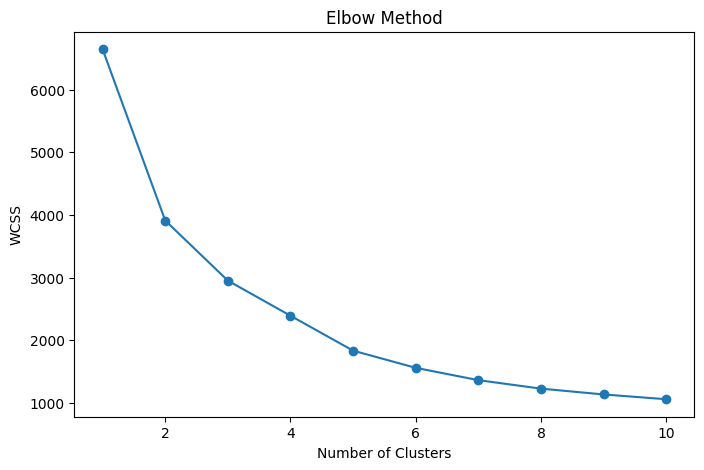

In [22]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [23]:
# Apply K-Means with 4 clusters

kmeans = KMeans(n_clusters=4, random_state=42)

df['Cluster'] = kmeans.fit_predict(scaled_features)

# Check first few rows
df[['Income', 'Age', 'Total_Spending', 'Cluster']].head()

,Income,Age,Total_Spending,Cluster
0,58138.0,69,1617,1
1,46344.0,72,27,2
2,71613.0,61,776,1
3,26646.0,42,53,0
4,58293.0,45,422,0


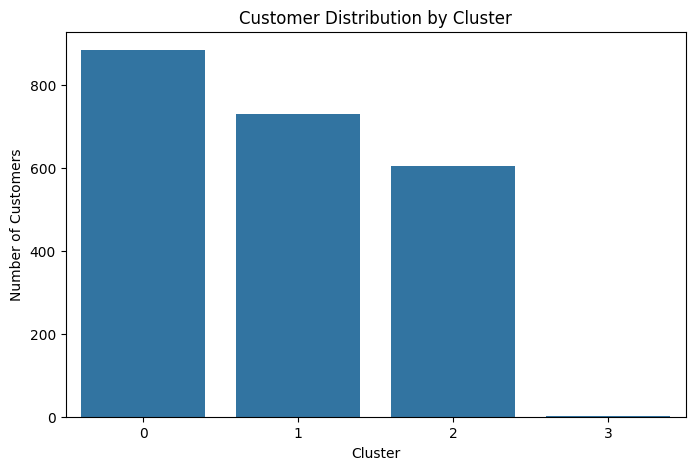

In [24]:
# Cluster Distribution

import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(x='Cluster', data=df)

plt.title('Customer Distribution by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.show()

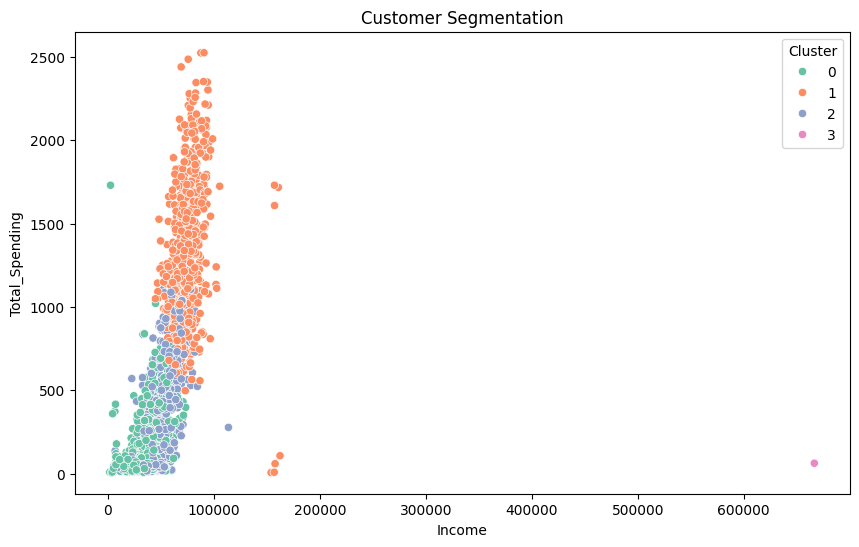

In [25]:
# Customer Segments Visualization

plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Income',
    y='Total_Spending',
    hue='Cluster',
    palette='Set2',
    data=df
)

plt.title('Customer Segmentation')
plt.show()

In [26]:
# Cluster Summary

cluster_summary = df.groupby('Cluster')[['Income','Age','Total_Spending']].mean()

cluster_summary

,Income,Age,Total_Spending
Cluster,,,
0,34711.318233,49.216308,152.546999
1,74271.984890,56.402473,1326.703297
2,50319.774834,69.771523,405.096026
3,666666.000000,49.000000,62.000000


# Business Insights

### Cluster 0
- Medium income customers
- Low spending behavior
- Can be targeted with discount campaigns

### Cluster 1
- Medium income customers
- Highest spending behavior
- Most valuable customer segment

### Cluster 2
- Older customers
- Moderate spending
- Suitable for loyalty programs

### Cluster 3
- Extremely high income customer
- Very small segment
- Premium/VIP marketing recommended

# Conclusion

Customer segmentation was successfully performed using K-Means Clustering. The customers were divided into four distinct groups based on Income, Age, and Total Spending. These insights can help businesses improve marketing strategies and customer retention.

In [27]:
print("Customer Segmentation Project Completed Successfully")

Customer Segmentation Project Completed Successfully
